
────────────────────────────────────────────────────────────
  Fig 1  – RMSD time-series
────────────────────────────────────────────────────────────


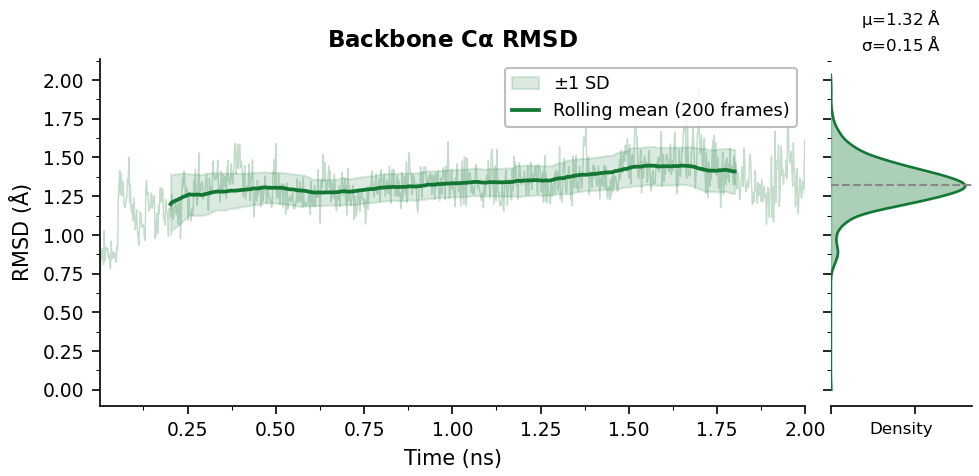


────────────────────────────────────────────────────────────
  Fig 2  – RMSF per residue
────────────────────────────────────────────────────────────


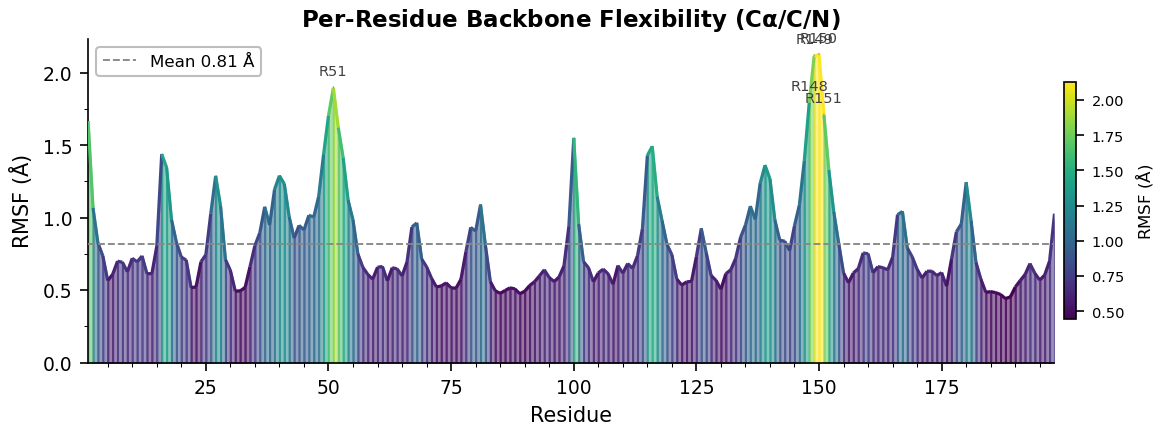


────────────────────────────────────────────────────────────
  Fig 3  – DSSP stacked area
────────────────────────────────────────────────────────────


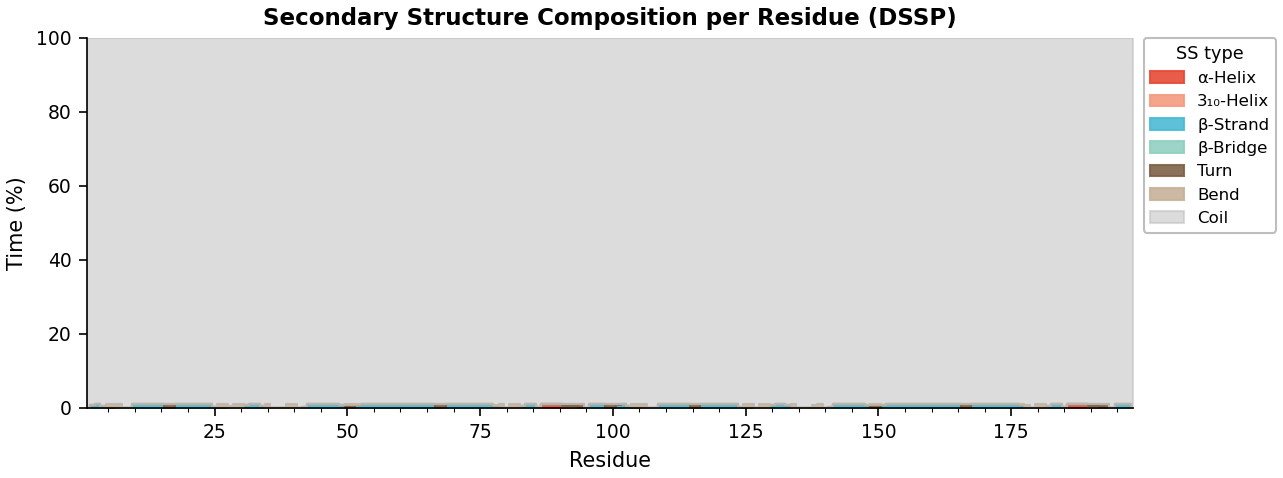


────────────────────────────────────────────────────────────
  Fig 4  – H-bond dashboard (PP/BB/PW/PL)
────────────────────────────────────────────────────────────


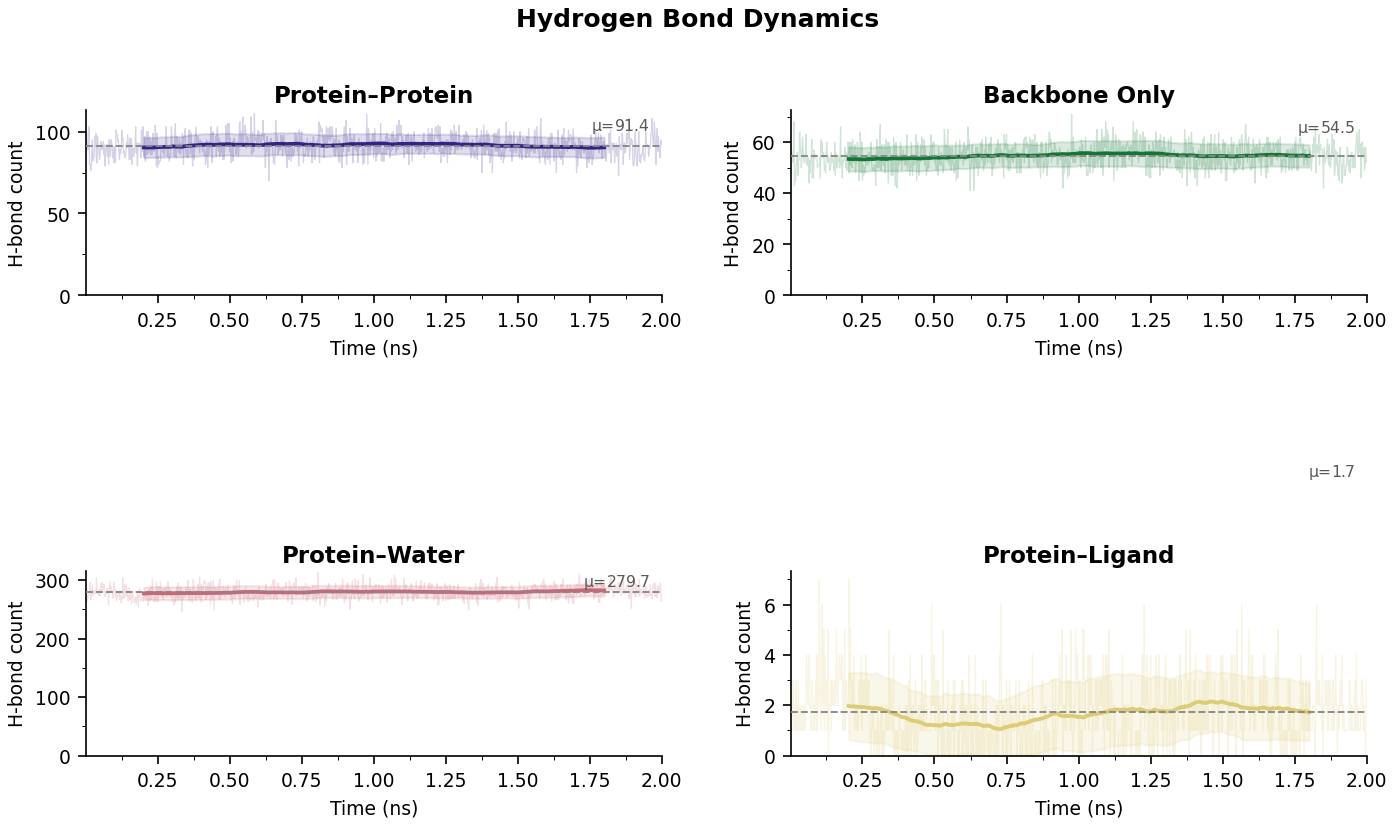


────────────────────────────────────────────────────────────
  Fig 5  – Water-bridge H-bonds
────────────────────────────────────────────────────────────


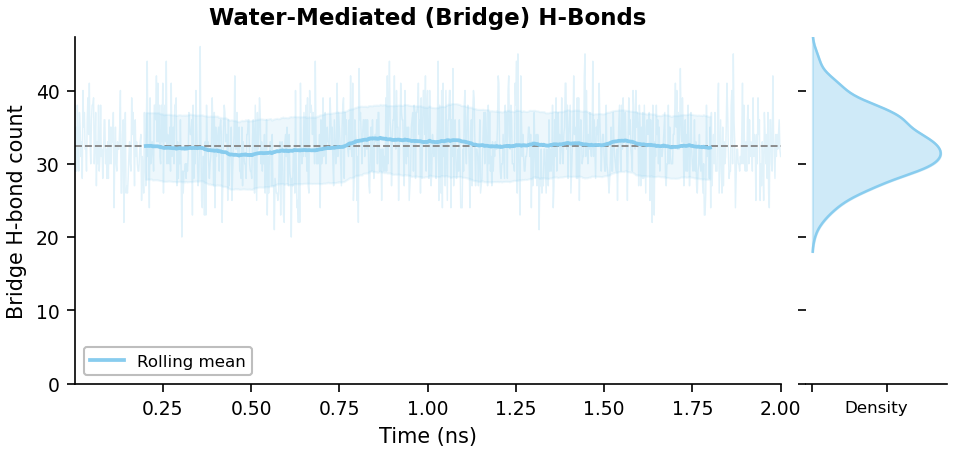


────────────────────────────────────────────────────────────
  Fig 6  – H-bond occupancy bars
────────────────────────────────────────────────────────────


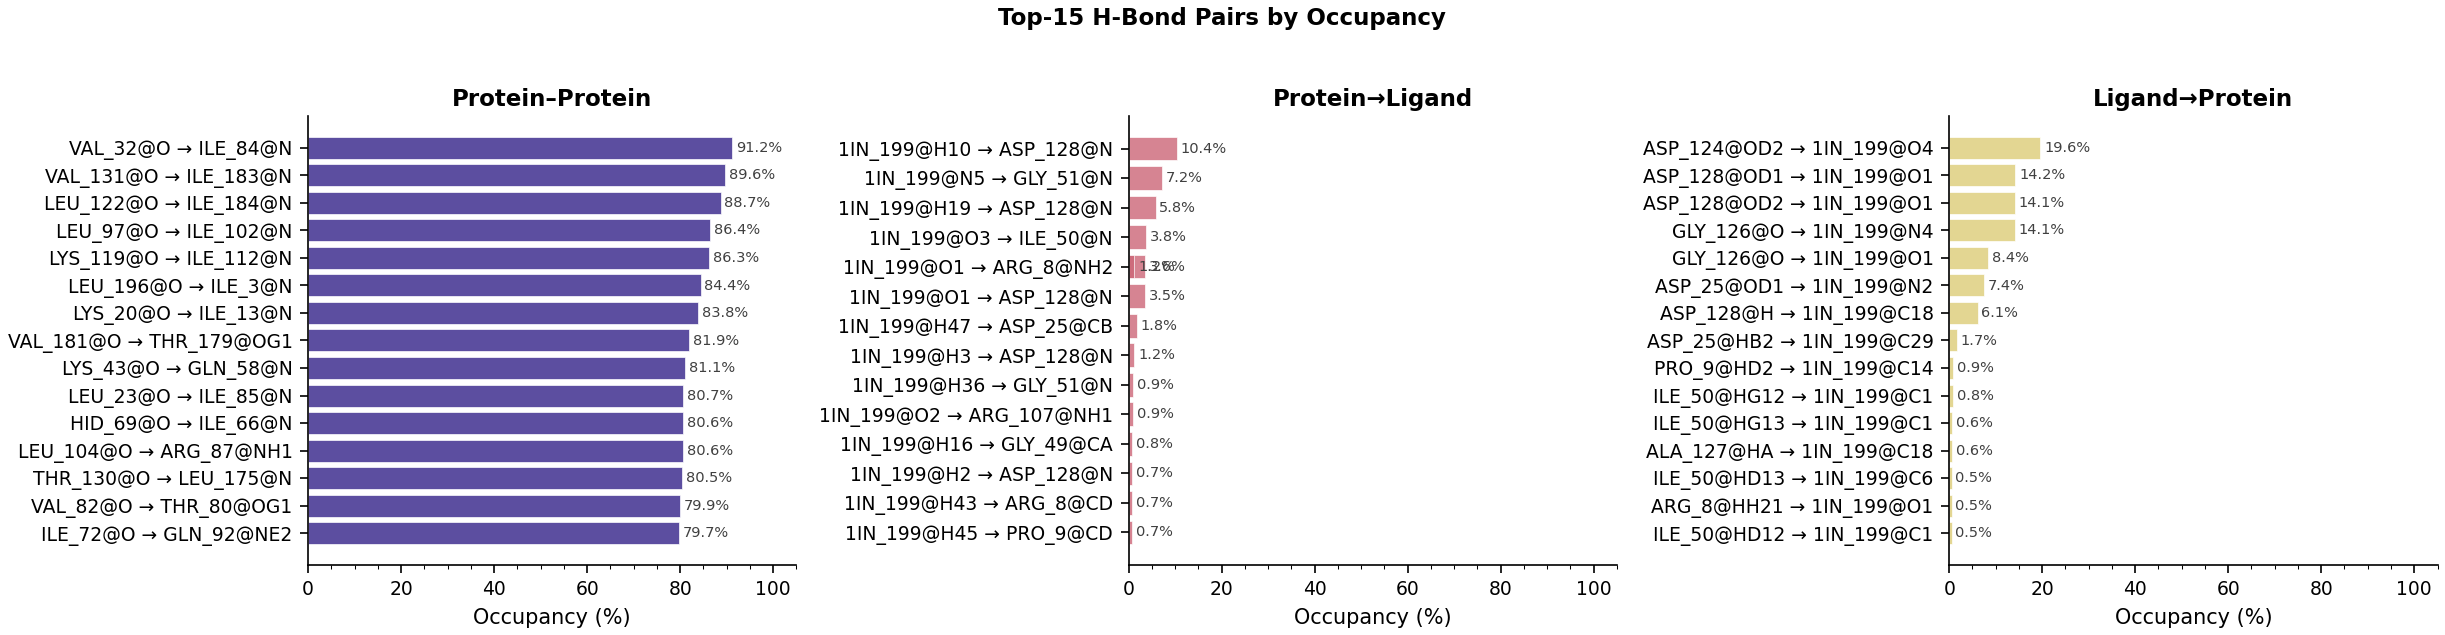


────────────────────────────────────────────────────────────
  Fig 7  – 2D Free-Energy Landscape
────────────────────────────────────────────────────────────


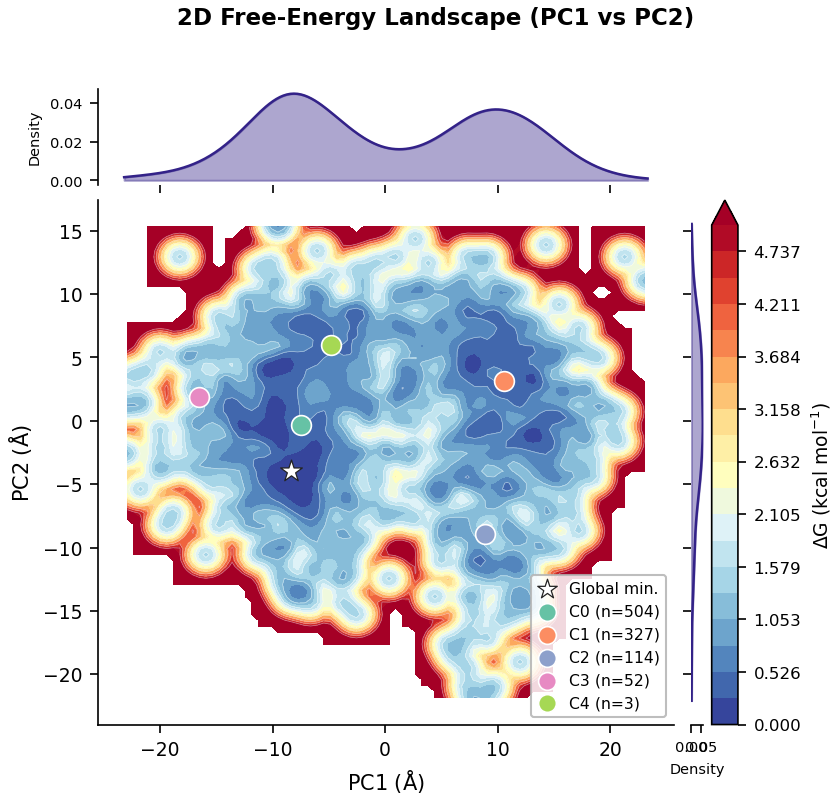


────────────────────────────────────────────────────────────
  Fig 8  – PC1 coloured by cluster
────────────────────────────────────────────────────────────


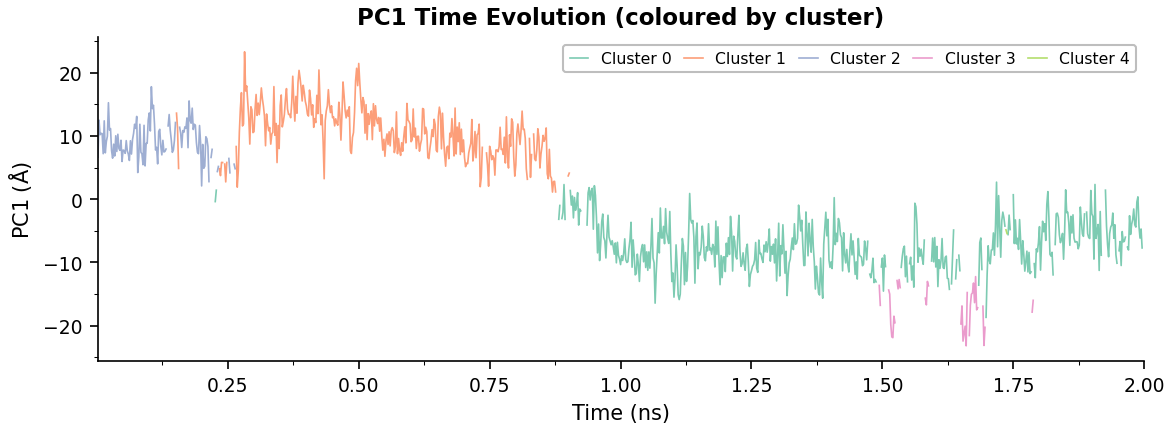


────────────────────────────────────────────────────────────
  Fig 9  – Cluster dashboard
────────────────────────────────────────────────────────────


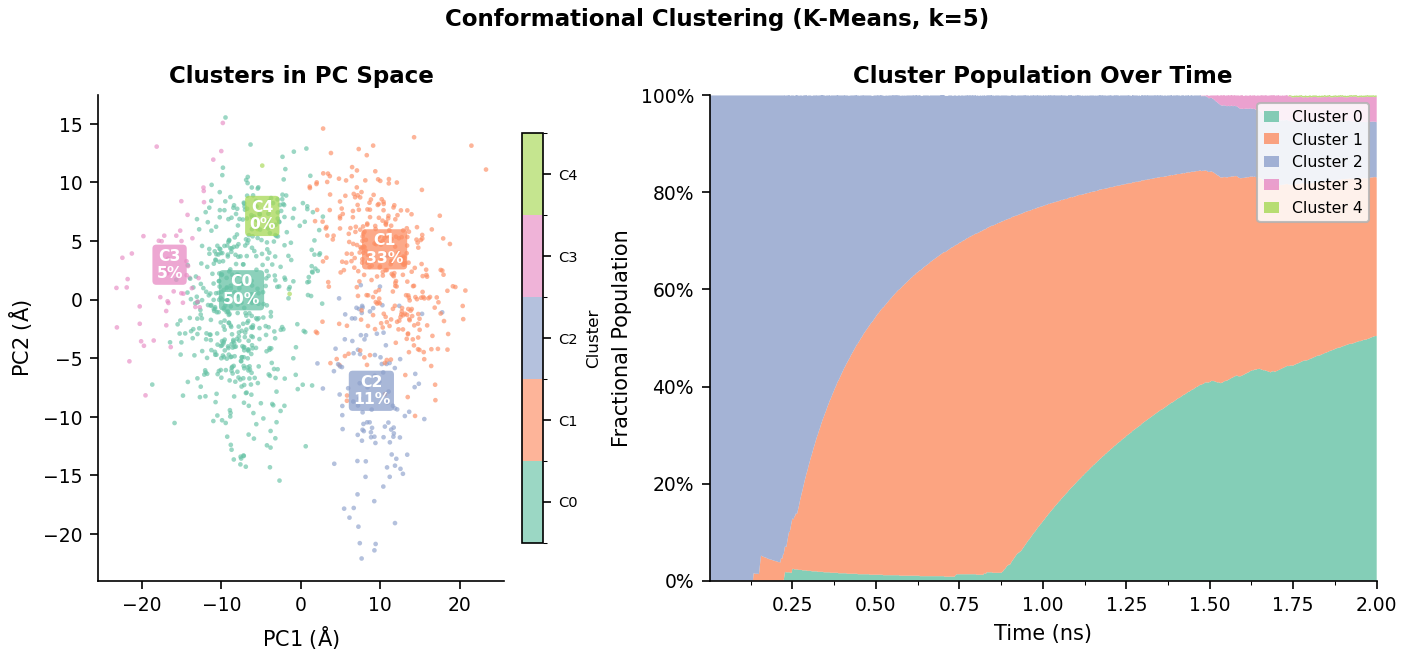


────────────────────────────────────────────────────────────
  Fig 10 – Master overview panel
────────────────────────────────────────────────────────────


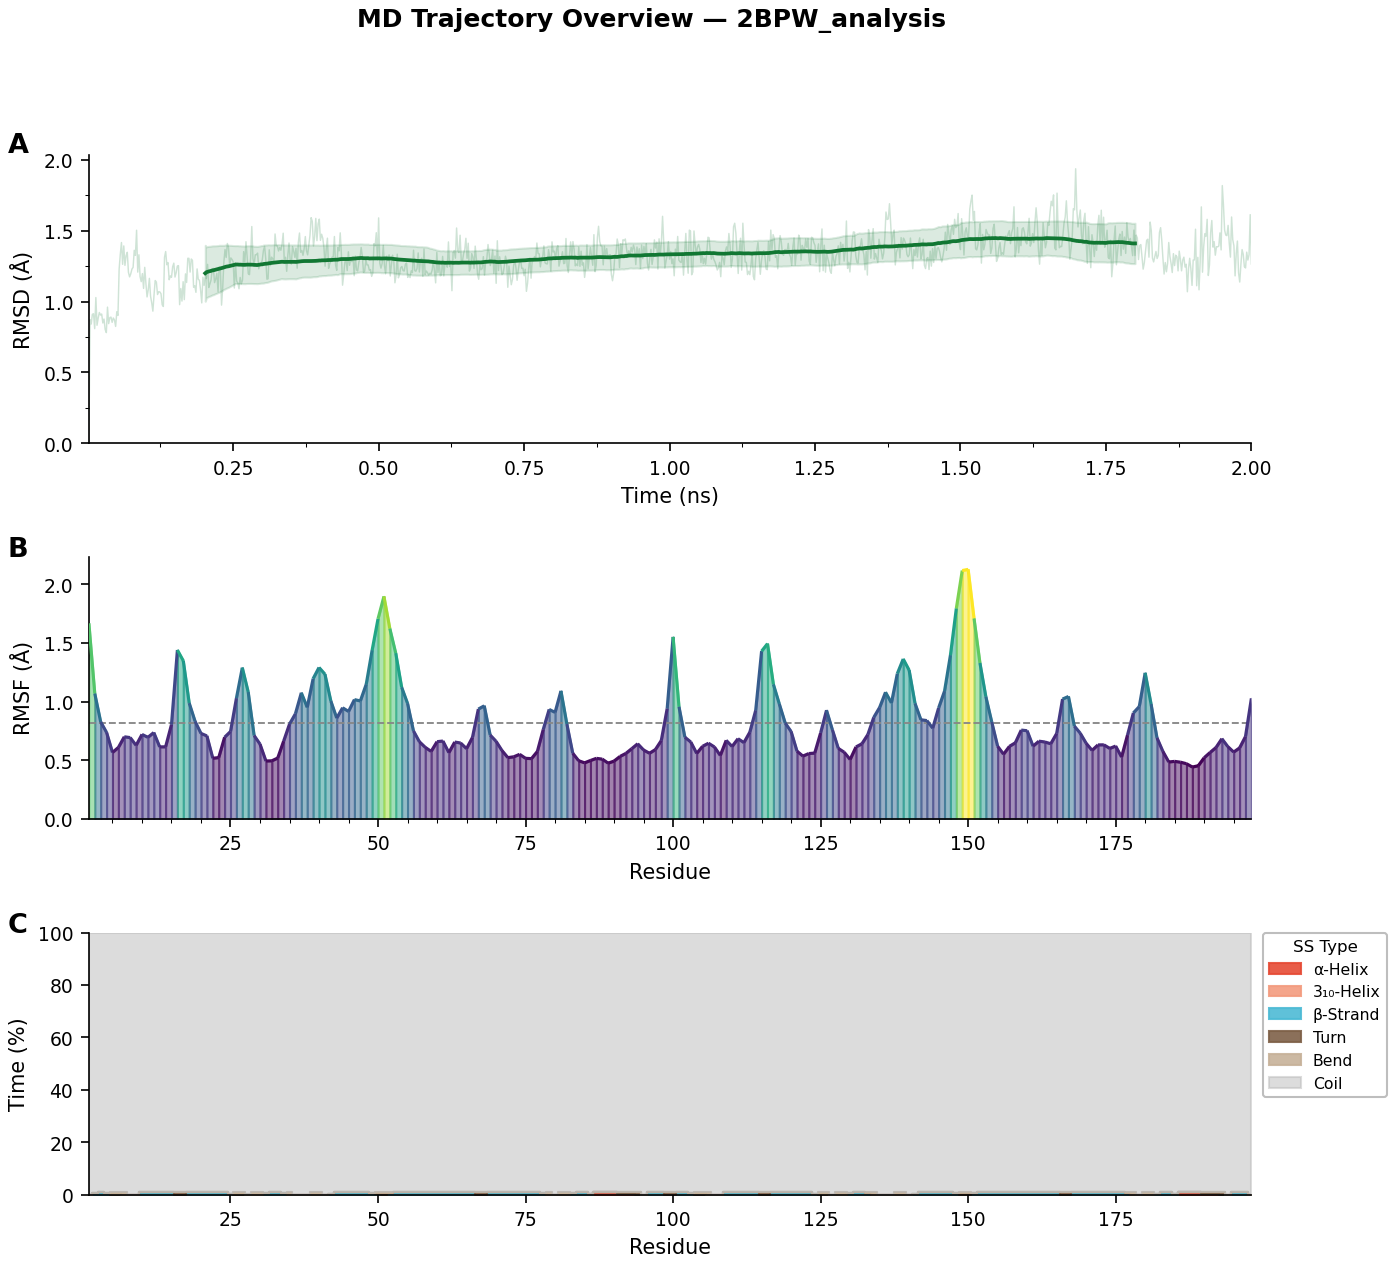


✓ All figures generated.


In [1]:
"""
=============================================================================
PUBLICATION-QUALITY MD ANALYSIS VISUALIZATION SUITE
=============================================================================
Designed to produce journal-ready figures (Nature / JACS / JCTC standard)
from cpptraj output files. Handles all output datasets from the attached
cpptraj template: RMSD, RMSF, DSSP, Hydrogen Bonds (PP/BB/PW/PL),
PCA Free-Energy Landscape, Cluster Population, and Bridge/Solvent HBonds.

USAGE
-----
1. Set `name` and `n_clusters` below to match your cpptraj run.
2. Run: python md_publication_viz.py
   Or paste cells into Jupyter.
=============================================================================
"""

# ─────────────────────────────────────────────────────────────────────────────
# CELL 0 ── Imports & global aesthetics
# ─────────────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
from matplotlib.collections import LineCollection
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter
import seaborn as sns

# ── Typography & rcParams (no external style sheets required) ────────────────
RC = {
    # Font
    "font.family":          "DejaVu Sans",
    "font.size":            10,
    "axes.titlesize":       11,
    "axes.labelsize":       10,
    "xtick.labelsize":      9,
    "ytick.labelsize":      9,
    "legend.fontsize":      8.5,
    "legend.title_fontsize":9,

    # Lines & ticks
    "axes.linewidth":       0.8,
    "xtick.major.width":    0.8,
    "ytick.major.width":    0.8,
    "xtick.minor.width":    0.5,
    "ytick.minor.width":    0.5,
    "xtick.major.size":     4.0,
    "ytick.major.size":     4.0,
    "xtick.minor.size":     2.0,
    "ytick.minor.size":     2.0,
    "xtick.direction":      "out",
    "ytick.direction":      "out",
    "lines.linewidth":      1.4,

    # Figure
    "figure.dpi":           150,
    "savefig.dpi":          300,
    "savefig.bbox":         "tight",
    "savefig.pad_inches":   0.05,

    # Grid
    "axes.grid":            False,

    # Legend
    "legend.frameon":       True,
    "legend.framealpha":    0.85,
    "legend.edgecolor":     "0.7",

    # Math text  (renders Å, kcal/mol, etc.)
    "mathtext.default":     "regular",
}
mpl.rcParams.update(RC)

# ── Colorblind-safe palette (Paul Tol "muted" family) ────────────────────────
TOL_MUTED = ["#332288", "#117733", "#44AA99", "#88CCEE",
             "#DDCC77", "#CC6677", "#AA4499", "#882255"]

ACCENT   = "#117733"   # green  – single-series highlight
ACCENT2  = "#332288"   # indigo – secondary
NEUTRAL  = "#888888"   # grey   – rolling averages / guides

# ── Utility helpers ──────────────────────────────────────────────────────────
def despine(ax, top=True, right=True, left=False, bottom=False):
    """Remove selected spines for a cleaner academic look."""
    if top:    ax.spines["top"].set_visible(False)
    if right:  ax.spines["right"].set_visible(False)
    if left:   ax.spines["left"].set_visible(False)
    if bottom: ax.spines["bottom"].set_visible(False)

def rolling(arr, window=100):
    """Centred rolling mean; edges padded with NaN."""
    out = np.full_like(arr, np.nan, dtype=float)
    hw  = window // 2
    for i in range(hw, len(arr) - hw):
        out[i] = arr[i - hw : i + hw].mean()
    return out

def rolling_std(arr, window=100):
    """Centred rolling std; edges NaN."""
    out = np.full_like(arr, np.nan, dtype=float)
    hw  = window // 2
    for i in range(hw, len(arr) - hw):
        out[i] = arr[i - hw : i + hw].std()
    return out

def load_cpptraj(path, skip_comment="#"):
    """Robust loader for cpptraj .dat files (skips '#' comment lines)."""
    return np.loadtxt(path, comments=skip_comment)

def frame_to_ns(frames, dt_ns=0.002):
    """Convert cpptraj frame index → nanoseconds."""
    return frames * dt_ns


# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 ── User configuration
# ─────────────────────────────────────────────────────────────────────────────
name       = "2BPW_analysis"   # ← set to match your cpptraj $name
n_clusters = 5               # ← set to match your cpptraj ${n_clusters}
DT_NS      = 0.002           # frame → nanoseconds conversion factor

# File paths (auto-derived from cpptraj template variable conventions)
rmsd_file      = f"rmsd_{name}.dat"
rmsf_file      = f"rmsf_bb_{name}.dat"
ss_file        = f"ss_summary{name}.dat"
PP_file        = f"PP_hbvtime_{name}.dat"
BB_file        = f"BB_hbvtime_{name}.dat"
PW_file        = f"PW_hbvtime_{name}.dat"
PL_file        = f"PL_hbvtime_{name}.dat"
pca_file       = f"pca_{name}.dat"
cnumvtime_file = f"cnumvtime_{name}.dat"
cpopvtime_file = f"cpopvtime_{name}.dat"
# Hydrogen bond AVERAGE files (used for occupancy bar charts)
PP_avg_file    = f"PP_avg_{name}.dat"
BB_avg_file    = f"BB_avg_{name}.dat"
PtoL_avg_file  = f"PtoL_avg_{name}.dat"
LtoP_avg_file  = f"LtoP_avg_{name}.dat"
# Bridge / solvent files from 'All' hbond action
Bridge_file    = f"Bridge_hbvtime_{name}.dat"

SAVE_FIGS = True          # set False to only plt.show()
FIG_DIR   = "."           # output directory for saved PDFs


# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 ── Figure 1: RMSD — time-series + rolling mean + marginal KDE
# ─────────────────────────────────────────────────────────────────────────────
# WHY: A bare RMSD line is noisy and hard to interpret. Adding a rolling mean
# reveals equilibration onset; a side KDE shows the conformational distribution
# directly, replacing a separate histogram cell.
# ─────────────────────────────────────────────────────────────────────────────

def plot_rmsd(rmsd_file, dt_ns=DT_NS, roll_window=200,
              color=ACCENT, save=SAVE_FIGS):
    raw    = load_cpptraj(rmsd_file)
    frames = raw[:, 0]
    rmsd   = raw[:, 1]
    time   = frame_to_ns(frames, dt_ns)

    rmsd_roll = rolling(rmsd, roll_window)
    rmsd_std  = rolling_std(rmsd, roll_window)

    # --- Layout: main timeseries | marginal KDE ---------------------------
    fig = plt.figure(figsize=(7.5, 3.0))
    gs  = gridspec.GridSpec(1, 2, width_ratios=[5, 1], wspace=0.06)
    ax  = fig.add_subplot(gs[0])
    axk = fig.add_subplot(gs[1], sharey=ax)

    # Raw trace (thin, low alpha)
    ax.plot(time, rmsd, color=color, alpha=0.25, lw=0.7, zorder=1)
    # SD corridor
    ax.fill_between(time,
                    rmsd_roll - rmsd_std,
                    rmsd_roll + rmsd_std,
                    color=color, alpha=0.15, zorder=2, label=r"$\pm$1 SD")
    # Rolling mean
    ax.plot(time, rmsd_roll, color=color, lw=1.8, zorder=3,
            label=f"Rolling mean ({roll_window} frames)")

    ax.set_xlabel(r"Time (ns)")
    ax.set_ylabel(r"RMSD ($\mathrm{\AA}$)")
    ax.set_xlim(time[0], time[-1])
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.legend(loc="upper right", handlelength=1.5)
    ax.set_title("Backbone C$\\alpha$ RMSD", fontweight="bold", pad=6)
    despine(ax)

    # Marginal KDE
    kde = gaussian_kde(rmsd, bw_method="scott")
    y_grid = np.linspace(rmsd.min() * 0.95, rmsd.max() * 1.05, 300)
    axk.fill_betweenx(y_grid, kde(y_grid), 0,
                      color=color, alpha=0.35)
    axk.plot(kde(y_grid), y_grid, color=color, lw=1.2)
    axk.set_xlabel("Density", fontsize=8)
    axk.axhline(np.mean(rmsd), color=NEUTRAL, lw=1.0, ls="--",
                label=f"Mean {np.mean(rmsd):.2f} Å")
    axk.set_xlim(left=0)
    despine(axk, left=True)
    axk.tick_params(labelleft=False, labelbottom=False)
    axk.set_title(f"$\mu$={np.mean(rmsd):.2f} Å\n$\sigma$={np.std(rmsd):.2f} Å",
                  fontsize=8, pad=4)

    plt.suptitle("", y=1.0)
    if save:
        fig.savefig(f"{FIG_DIR}/Fig1_RMSD_{name}.pdf")
    plt.show()
    return fig

# plot_rmsd(rmsd_file)   # ← uncomment when files are present


# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 ── Figure 2: RMSF per residue — gradient ribbon + annotated peaks
# ─────────────────────────────────────────────────────────────────────────────
# WHY: A simple RMSF line gives no sense of relative magnitude across the
# sequence. A filled gradient ribbon + colour-coded line immediately flags
# the most mobile regions without needing annotation; a dashed mean line
# gives a quick threshold for "flexible vs. rigid".
# ─────────────────────────────────────────────────────────────────────────────

def plot_rmsf(rmsf_file, top_n_peaks=5, save=SAVE_FIGS):
    raw   = load_cpptraj(rmsf_file)
    res   = raw[:, 0].astype(int)
    rmsf  = raw[:, 1]

    # Colour segments by RMSF magnitude (viridis)
    norm_vals = (rmsf - rmsf.min()) / (rmsf.max() - rmsf.min() + 1e-9)
    cmap = plt.cm.get_cmap("viridis")

    fig, ax = plt.subplots(figsize=(8.5, 2.8))

    # Gradient fill  (step through segments)
    for i in range(len(res) - 1):
        c = cmap(norm_vals[i])
        ax.fill_between(res[i:i+2], rmsf[i:i+2], alpha=0.55, color=c)
    # Coloured line
    points  = np.array([res, rmsf]).T.reshape(-1, 1, 2)
    segs    = np.concatenate([points[:-1], points[1:]], axis=1)
    lc      = LineCollection(segs, cmap="viridis",
                             norm=mcolors.Normalize(rmsf.min(), rmsf.max()),
                             linewidth=1.5, zorder=3)
    lc.set_array(rmsf)
    ax.add_collection(lc)

    # Mean dashed line
    mean_rmsf = np.mean(rmsf)
    ax.axhline(mean_rmsf, color=NEUTRAL, lw=0.9, ls="--", zorder=4,
               label=f"Mean {mean_rmsf:.2f} Å")

    # Annotate top-N most mobile residues
    peak_idx = np.argsort(rmsf)[-top_n_peaks:]
    for idx in peak_idx:
        ax.annotate(f"R{res[idx]}",
                    xy=(res[idx], rmsf[idx]),
                    xytext=(0, 6), textcoords="offset points",
                    fontsize=7, ha="center", color="0.25",
                    arrowprops=dict(arrowstyle="-", color="0.6", lw=0.6))

    cbar = fig.colorbar(lc, ax=ax, pad=0.01, fraction=0.012)
    cbar.set_label(r"RMSF ($\mathrm{\AA}$)", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    ax.set_xlim(res[0], res[-1])
    ax.set_ylim(0)
    ax.set_xlabel("Residue")
    ax.set_ylabel(r"RMSF ($\mathrm{\AA}$)")
    ax.set_title("Per-Residue Backbone Flexibility (C$\\alpha$/C/N)", fontweight="bold")
    ax.legend(loc="upper left", fontsize=8)
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    despine(ax)

    if save:
        fig.savefig(f"{FIG_DIR}/Fig2_RMSF_{name}.pdf")
    plt.show()
    return fig

# plot_rmsf(rmsf_file)


# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 ── Figure 3: Secondary Structure — stacked area per residue
# ─────────────────────────────────────────────────────────────────────────────
# WHY: The original 3-panel line plot stacks three separate y-axes and makes
# cross-residue comparison hard. A single stacked area chart on one panel
# shows total SS coverage and the proportion of each type simultaneously,
# matching the "sumout" data produced by DSSP in cpptraj.
# The colour palette is drawn from a perceptually-distinct set tied to
# conventional secondary structure colouring used in VMD/PyMOL publications.
# ─────────────────────────────────────────────────────────────────────────────

SS_COLORS = {
    "α-Helix":   "#E64B35",   # red
    "3₁₀-Helix": "#F39B7F",   # salmon
    "π-Helix":   "#B09C85",   # taupe
    "β-Strand":  "#4DBBD5",   # teal
    "β-Bridge":  "#91D1C2",   # mint
    "Turn":      "#7E6148",   # brown
    "Bend":      "#C7B299",   # tan
}

def plot_dssp(ss_file, save=SAVE_FIGS):
    """
    Reads cpptraj DSSP sumout columns:
    [0]=Resid [1]=Extended [2]=Bridge [3]=3-10 [4]=Alpha [5]=Pi [6]=Turn [7]=Bend
    Values are percentage of trajectory time (0–100).
    """
    data = load_cpptraj(ss_file)
    res  = data[:, 0].astype(int)
    ss = {
        "α-Helix":   data[:, 4],
        "3₁₀-Helix": data[:, 3],
        "π-Helix":   data[:, 5],
        "β-Strand":  data[:, 1],
        "β-Bridge":  data[:, 2],
        "Turn":      data[:, 6],
        "Bend":      data[:, 7],
    }

    fig, ax = plt.subplots(figsize=(9.0, 3.2))

    bottom = np.zeros(len(res))
    for label, values in ss.items():
        if values.sum() < 0.1:        # skip empty types
            continue
        ax.fill_between(res, bottom, bottom + values,
                        color=SS_COLORS[label], alpha=0.90,
                        label=label, step="mid")
        bottom += values

    # Coil = remainder
    coil = np.clip(100.0 - bottom, 0, 100)
    ax.fill_between(res, bottom, bottom + coil,
                    color="#BBBBBB", alpha=0.5, label="Coil", step="mid")

    ax.set_xlim(res[0], res[-1])
    ax.set_ylim(0, 100)
    ax.set_xlabel("Residue")
    ax.set_ylabel("Time (%)")
    ax.set_title("Secondary Structure Composition per Residue (DSSP)", fontweight="bold")
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))

    # Compact legend to the right
    leg = ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0),
                    borderaxespad=0, frameon=True, fontsize=8,
                    title="SS type", title_fontsize=8.5)
    despine(ax)

    if save:
        fig.savefig(f"{FIG_DIR}/Fig3_DSSP_{name}.pdf", bbox_inches="tight")
    plt.show()
    return fig

# plot_dssp(ss_file)


# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 ── Figure 4: Hydrogen Bond Dashboard — 2×2 panel
# ─────────────────────────────────────────────────────────────────────────────
# WHY: The original notebook plots each HB type as a separate, identical
# figure — four almost-identical charts that users must scroll through.
# A 2×2 dashboard lets readers compare all four simultaneously.
# Each panel uses the same rolling-mean + SD-ribbon treatment as RMSD
# and adopts a distinct colour so panels are visually distinguishable.
# A shared y-limit block emphasises relative magnitude differences.
# ─────────────────────────────────────────────────────────────────────────────

HB_META = [
    ("Protein–Protein",          PP_file,  "#332288"),
    ("Backbone Only",            BB_file,  "#117733"),
    ("Protein–Water",            PW_file,  "#CC6677"),
    ("Protein–Ligand",           PL_file,  "#DDCC77"),
]

def plot_hbond_dashboard(hb_meta=HB_META, dt_ns=DT_NS,
                         roll_window=200, save=SAVE_FIGS):
    fig, axes = plt.subplots(2, 2, figsize=(9.5, 5.5), sharey=False)
    axes = axes.flatten()

    global_max = 0
    datasets   = {}
    for label, fpath, color in hb_meta:
        try:
            raw = load_cpptraj(fpath)
            t   = frame_to_ns(raw[:, 0], dt_ns)
            hb  = raw[:, 1]
            datasets[label] = (t, hb, color)
            global_max = max(global_max, np.nanmax(hb))
        except Exception:
            datasets[label] = None

    for ax, (label, fpath, color) in zip(axes, hb_meta):
        entry = datasets[label]
        if entry is None:
            ax.text(0.5, 0.5, f"{label}\n(file not found)",
                    ha="center", va="center", transform=ax.transAxes,
                    color="0.5", fontsize=9)
            despine(ax)
            continue
        t, hb, c = entry
        r   = rolling(hb, roll_window)
        std = rolling_std(hb, roll_window)

        ax.plot(t, hb,    color=c, alpha=0.20, lw=0.6, zorder=1)
        ax.fill_between(t, r - std, r + std, color=c, alpha=0.15, zorder=2)
        ax.plot(t, r,      color=c, lw=1.8, zorder=3)

        mean_hb = np.nanmean(hb)
        ax.axhline(mean_hb, color=NEUTRAL, lw=0.9, ls="--", zorder=4)
        ax.text(t[-1] * 0.98, mean_hb + global_max * 0.03,
                f"$\\mu$={mean_hb:.1f}", ha="right", fontsize=7.5, color="0.35")

        ax.set_title(label, fontweight="bold", pad=4)
        ax.set_xlabel("Time (ns)", fontsize=9)
        ax.set_ylabel("H-bond count", fontsize=9)
        ax.set_xlim(t[0], t[-1])
        ax.set_ylim(0)
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.xaxis.set_minor_locator(AutoMinorLocator(2))
        despine(ax)

    fig.suptitle("Hydrogen Bond Dynamics", fontsize=12, fontweight="bold", y=1.01)
    plt.tight_layout(h_pad=2.5, w_pad=2.0)
    if save:
        fig.savefig(f"{FIG_DIR}/Fig4_HBonds_Dashboard_{name}.pdf")
    plt.show()
    return fig

# plot_hbond_dashboard()


# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 ── Figure 5: Protein–Water Bridge Hydrogen Bonds (NEW — unused data)
# ─────────────────────────────────────────────────────────────────────────────
# WHY: The cpptraj 'bridgeout' action writes water-mediated bridges between
# protein residues — a dataset the original notebook never reads. Bridging
# water molecules are functionally important (active site solvation, allosteric
# paths). A time-series with KDE gives the first look at bridge stability.
# ─────────────────────────────────────────────────────────────────────────────

def plot_bridge_hbonds(bridge_file=Bridge_file, dt_ns=DT_NS,
                       roll_window=200, save=SAVE_FIGS):
    try:
        raw  = load_cpptraj(bridge_file)
    except Exception:
        print(f"[skip] Bridge HB file not found: {bridge_file}")
        return None

    t    = frame_to_ns(raw[:, 0], dt_ns)
    hb   = raw[:, 1]
    r    = rolling(hb, roll_window)
    std  = rolling_std(hb, roll_window)

    fig = plt.figure(figsize=(7.5, 3.0))
    gs  = gridspec.GridSpec(1, 2, width_ratios=[5, 1], wspace=0.06)
    ax  = fig.add_subplot(gs[0])
    axk = fig.add_subplot(gs[1], sharey=ax)

    c = "#88CCEE"   # sky blue
    ax.plot(t, hb, color=c, alpha=0.25, lw=0.7, zorder=1)
    ax.fill_between(t, r - std, r + std, color=c, alpha=0.15, zorder=2)
    ax.plot(t, r,   color=c, lw=1.8, zorder=3, label="Rolling mean")
    ax.axhline(np.nanmean(hb), color=NEUTRAL, lw=0.9, ls="--")
    ax.set_xlabel("Time (ns)")
    ax.set_ylabel("Bridge H-bond count")
    ax.set_title("Water-Mediated (Bridge) H-Bonds", fontweight="bold")
    ax.set_xlim(t[0], t[-1]); ax.set_ylim(0)
    ax.legend(fontsize=8)
    despine(ax)

    kde    = gaussian_kde(hb[~np.isnan(hb)], bw_method="scott")
    y_grid = np.linspace(hb.min() * 0.9, hb.max() * 1.1, 300)
    axk.fill_betweenx(y_grid, kde(y_grid), 0, color=c, alpha=0.40)
    axk.plot(kde(y_grid), y_grid, color=c, lw=1.2)
    axk.tick_params(labelleft=False, labelbottom=False)
    axk.set_xlabel("Density", fontsize=8)
    despine(axk, left=True)

    if save:
        fig.savefig(f"{FIG_DIR}/Fig5_BridgeHBonds_{name}.pdf")
    plt.show()
    return fig

# plot_bridge_hbonds()


# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 ── Figure 6: H-bond Occupancy Bar Charts from avgout files (NEW)
# ─────────────────────────────────────────────────────────────────────────────
# WHY: The avgout / solvout files list SPECIFIC donor–acceptor pairs with
# their occupancy (% of frames). The original notebook ignores these entirely.
# Horizontal bar charts of the top-N pairs immediately identify the most
# persistent hydrogen bonds — key for understanding binding and stability.
# ─────────────────────────────────────────────────────────────────────────────

def _load_hbavg(path, top_n=20):
    """
    Parse cpptraj avgout format:
    #Donor  DonorH  Acceptor  Frames  Frac  AvgDist  AvgAng
    """
    rows = []
    try:
        with open(path) as fh:
            for line in fh:
                line = line.strip()
                if line.startswith("#") or not line:
                    continue
                parts = line.split()
                if len(parts) < 5:
                    continue
                try:
                    donor    = parts[0]
                    acceptor = parts[2]
                    frac     = float(parts[4])
                    rows.append({"pair": f"{donor} → {acceptor}", "occ": frac * 100})
                except (ValueError, IndexError):
                    continue
    except FileNotFoundError:
        return None
    df = pd.DataFrame(rows).sort_values("occ", ascending=False).head(top_n)
    return df

def plot_hbond_occupancy(files_labels, top_n=15, save=SAVE_FIGS):
    """
    files_labels: list of (path, label, color) tuples
    One horizontal bar chart per file, arranged vertically in a single figure.
    """
    valid = [(f, l, c) for f, l, c in files_labels
             if _load_hbavg(f) is not None and len(_load_hbavg(f)) > 0]

    if not valid:
        print("[skip] No avgout files found — run cpptraj first.")
        return None

    n_panels = len(valid)
    fig, axes = plt.subplots(1, n_panels,
                             figsize=(5.5 * n_panels, max(3.5, top_n * 0.28)))

    if n_panels == 1:
        axes = [axes]

    for ax, (fpath, label, color) in zip(axes, valid):
        df = _load_hbavg(fpath, top_n)
        bars = ax.barh(df["pair"], df["occ"],
                       color=color, alpha=0.80, edgecolor="white", linewidth=0.4)
        # Value labels on bars
        for bar, val in zip(bars, df["occ"]):
            ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2,
                    f"{val:.1f}%", va="center", fontsize=7, color="0.25")

        ax.set_xlim(0, 105)
        ax.set_xlabel("Occupancy (%)")
        ax.set_title(label, fontweight="bold", pad=5)
        ax.invert_yaxis()
        ax.xaxis.set_minor_locator(MultipleLocator(5))
        despine(ax)

    fig.suptitle(f"Top-{top_n} H-Bond Pairs by Occupancy", fontsize=11,
                 fontweight="bold", y=1.02)
    plt.tight_layout()
    if save:
        fig.savefig(f"{FIG_DIR}/Fig6_HBond_Occupancy_{name}.pdf", bbox_inches="tight")
    plt.show()
    return fig

# Example call (PL most interesting for drug-binding projects):
# plot_hbond_occupancy([
#     (PP_avg_file,   "Protein–Protein",  "#332288"),
#     (PtoL_avg_file, "Protein→Ligand",   "#CC6677"),
#     (LtoP_avg_file, "Ligand→Protein",   "#DDCC77"),
# ])


# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 ── Figure 7: PCA Free-Energy Landscape (FEL)
# ─────────────────────────────────────────────────────────────────────────────
# WHY: The original notebook does a KDE scatter, which only shows density —
# not free energy. A proper 2D FEL (ΔG = –kT ln P) with filled contours,
# thermodynamic minimum annotation, and cluster centroid overlay is the
# standard in JACS/JCTC PCA sections. We also add marginal KDEs on the axes.
# ─────────────────────────────────────────────────────────────────────────────

KB_T = 0.5961   # kB*T at 300 K in kcal/mol

def compute_fel(pc1, pc2, bins=80, sigma=1.2):
    """Return meshgrid (X, Y) and free energy dG (kcal/mol) from PCA coords."""
    H, xedges, yedges = np.histogram2d(pc1, pc2, bins=bins,
                                       density=True)
    H  = gaussian_filter(H, sigma=sigma)
    H  = np.where(H > 0, H, np.nan)
    dG = -KB_T * np.log(H)
    dG -= np.nanmin(dG)
    X  = 0.5 * (xedges[:-1] + xedges[1:])
    Y  = 0.5 * (yedges[:-1] + yedges[1:])
    return X, Y, dG.T

def plot_fel(pca_file, cnumvtime_file=None, dt_ns=DT_NS,
             n_clusters_plot=None, save=SAVE_FIGS):
    raw    = load_cpptraj(pca_file)
    frames = raw[:, 0]
    pc1    = raw[:, 1]
    pc2    = raw[:, 2]
    time   = frame_to_ns(frames, dt_ns)

    X, Y, dG = compute_fel(pc1, pc2)

    # Grid layout: FEL + marginal KDEs
    fig = plt.figure(figsize=(6.0, 5.5))
    gs  = gridspec.GridSpec(2, 2,
                            width_ratios=[5.5, 1.0],
                            height_ratios=[1.0, 5.5],
                            hspace=0.05, wspace=0.05)
    ax_main  = fig.add_subplot(gs[1, 0])
    ax_top   = fig.add_subplot(gs[0, 0], sharex=ax_main)
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

    # ── FEL filled contours
    levels = np.linspace(0, min(np.nanmax(dG), 5.0), 20)   # 0–5 kcal/mol
    cset   = ax_main.contourf(X, Y, dG, levels=levels,
                               cmap="RdYlBu_r", extend="max")
    ax_main.contour(X, Y, dG, levels=levels[::2],
                    colors="white", linewidths=0.35, alpha=0.5)

    cbar = fig.colorbar(cset, ax=ax_right, fraction=0.8, pad=0.08,
                        orientation="vertical")
    cbar.set_label(r"$\Delta G$ (kcal mol$^{-1}$)", fontsize=9)
    cbar.ax.tick_params(labelsize=8)

    # Thermodynamic minimum
    min_idx = np.unravel_index(np.nanargmin(dG), dG.shape)
    ax_main.scatter(X[min_idx[1]], Y[min_idx[0]],
                    marker="*", s=120, color="white",
                    edgecolors="#222222", linewidths=0.6, zorder=10,
                    label="Global min.")

    # Cluster centroids overlay
    if cnumvtime_file:
        try:
            cdata    = load_cpptraj(cnumvtime_file)
            clusters = cdata[:, 1].astype(int)
            n_cl     = n_clusters_plot or int(clusters.max()) + 1
            cpal     = plt.cm.Set2.colors
            for cid in range(n_cl):
                mask = clusters == cid
                if mask.sum() == 0:
                    continue
                cx, cy = np.median(pc1[mask]), np.median(pc2[mask])
                col    = cpal[cid % len(cpal)]
                ax_main.scatter(cx, cy, s=90, color=col,
                                edgecolors="white", linewidths=0.8,
                                zorder=11, label=f"C{cid} (n={mask.sum()})")
        except Exception as e:
            pass

    ax_main.set_xlabel(r"PC1 ($\mathrm{\AA}$)")
    ax_main.set_ylabel(r"PC2 ($\mathrm{\AA}$)")
    ax_main.legend(loc="lower right", fontsize=7.5, handlelength=1.2,
                   markerscale=0.9)
    despine(ax_main)

    # ── Marginal KDE – top
    kde1 = gaussian_kde(pc1, bw_method="scott")
    x_g  = np.linspace(pc1.min(), pc1.max(), 300)
    ax_top.fill_between(x_g, kde1(x_g), 0, color=ACCENT2, alpha=0.4)
    ax_top.plot(x_g, kde1(x_g), color=ACCENT2, lw=1.2)
    ax_top.set_ylabel("Density", fontsize=7)
    ax_top.tick_params(labelbottom=False, labelsize=7)
    despine(ax_top, bottom=True)

    # ── Marginal KDE – right
    kde2 = gaussian_kde(pc2, bw_method="scott")
    y_g  = np.linspace(pc2.min(), pc2.max(), 300)
    ax_right.fill_betweenx(y_g, kde2(y_g), 0, color=ACCENT2, alpha=0.4)
    ax_right.plot(kde2(y_g), y_g, color=ACCENT2, lw=1.2)
    ax_right.tick_params(labelleft=False, labelsize=7)
    ax_right.set_xlabel("Density", fontsize=7)
    despine(ax_right, left=True)

    fig.suptitle("2D Free-Energy Landscape (PC1 vs PC2)", fontsize=11,
                 fontweight="bold", y=0.98)
    if save:
        fig.savefig(f"{FIG_DIR}/Fig7_FEL_{name}.pdf")
    plt.show()
    return fig

# plot_fel(pca_file, cnumvtime_file, n_clusters_plot=n_clusters)


# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 ── Figure 8: PC1 Time Evolution — coloured by cluster assignment
# ─────────────────────────────────────────────────────────────────────────────
# WHY: The original notebook plots a raw PC1 time series with no colour.
# Colouring the line segments by cluster membership directly links the
# clustering result back to the trajectory timeline, revealing when and how
# long each conformational state is visited.
# ─────────────────────────────────────────────────────────────────────────────

def plot_pc1_time(pca_file, cnumvtime_file, dt_ns=DT_NS, save=SAVE_FIGS):
    raw      = load_cpptraj(pca_file)
    frames   = raw[:, 0]
    pc1      = raw[:, 1]
    time     = frame_to_ns(frames, dt_ns)

    cdata    = load_cpptraj(cnumvtime_file)
    clusters = cdata[:, 1].astype(int)
    n_cl     = int(clusters.max()) + 1

    fig, ax = plt.subplots(figsize=(9.0, 2.8))
    cpal    = [mcolors.to_hex(c) for c in plt.cm.Set2.colors[:n_cl]]

    # Plot per-cluster segments
    for cid in range(n_cl):
        mask = clusters == cid
        seg_t   = np.where(mask, time,  np.nan)
        seg_pc1 = np.where(mask, pc1, np.nan)
        ax.plot(seg_t, seg_pc1, color=cpal[cid], lw=0.8, alpha=0.85,
                label=f"Cluster {cid}")

    ax.set_xlabel("Time (ns)")
    ax.set_ylabel(r"PC1 ($\mathrm{\AA}$)")
    ax.set_title("PC1 Time Evolution (coloured by cluster)", fontweight="bold")
    ax.set_xlim(time[0], time[-1])
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.legend(loc="upper right", fontsize=7.5, ncol=n_cl,
              handlelength=1.2, columnspacing=0.8)
    despine(ax)

    if save:
        fig.savefig(f"{FIG_DIR}/Fig8_PC1_time_{name}.pdf")
    plt.show()
    return fig

# plot_pc1_time(pca_file, cnumvtime_file)


# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 ── Figure 9: Cluster Dashboard (PCA scatter + population timeline)
# ─────────────────────────────────────────────────────────────────────────────
# WHY: The original notebook renders the cluster PCA scatter and population
# timeline as two isolated plots. Side-by-side on a shared colormap, they
# answer TWO questions at once: "Where are the clusters in conformational
# space?" and "How do they evolve over simulation time?"
# ─────────────────────────────────────────────────────────────────────────────

def plot_cluster_dashboard(pca_file, cnumvtime_file, cpopvtime_file,
                           dt_ns=DT_NS, n_cl=n_clusters, save=SAVE_FIGS):
    # Load PCA
    raw_pca  = load_cpptraj(pca_file)
    pc1      = raw_pca[:, 1]
    pc2      = raw_pca[:, 2]

    # Load cluster membership
    cdata    = load_cpptraj(cnumvtime_file)
    clusters = cdata[:, 1].astype(int)
    n_cl     = max(n_cl, int(clusters.max()) + 1)

    # Load fractional population over time
    pop_df = pd.read_csv(cpopvtime_file, sep=r"\s+", comment="#", header=None)
    pop_t  = frame_to_ns(pop_df.iloc[:, 0].values, dt_ns)
    pop    = pop_df.iloc[:, 1:n_cl + 1].values   # shape (frames, n_cl)

    # Discrete palette
    cpal = [mcolors.to_hex(c) for c in plt.cm.Set2.colors[:n_cl]]

    fig = plt.figure(figsize=(11.0, 4.2))
    gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1.5], wspace=0.30)
    ax_pca = fig.add_subplot(gs[0])
    ax_pop = fig.add_subplot(gs[1])

    # ── Left: PCA scatter coloured by cluster ────────────────────────────
    bounds = np.arange(-0.5, n_cl + 0.5, 1)
    cmap_d = mcolors.ListedColormap(cpal)
    norm_d = mcolors.BoundaryNorm(bounds, cmap_d.N)

    sc = ax_pca.scatter(pc1, pc2, c=clusters, cmap=cmap_d, norm=norm_d,
                        s=5, alpha=0.65, edgecolors="none", rasterized=True)

    for cid in range(n_cl):
        mask = clusters == cid
        if mask.sum() == 0:
            continue
        cx, cy = np.median(pc1[mask]), np.median(pc2[mask])
        pct = mask.mean() * 100
        ax_pca.text(cx, cy, f"C{cid}\n{pct:.0f}%",
                    fontsize=7.5, fontweight="bold", ha="center", color="white",
                    bbox=dict(boxstyle="round,pad=0.25", fc=cpal[cid],
                              alpha=0.75, ec="none"))

    cbar = fig.colorbar(sc, ax=ax_pca, ticks=range(n_cl),
                        fraction=0.046, pad=0.04)
    cbar.set_label("Cluster", fontsize=8)
    cbar.ax.set_yticklabels([f"C{i}" for i in range(n_cl)], fontsize=7)

    ax_pca.set_xlabel(r"PC1 ($\mathrm{\AA}$)")
    ax_pca.set_ylabel(r"PC2 ($\mathrm{\AA}$)")
    ax_pca.set_title("Clusters in PC Space", fontweight="bold")
    despine(ax_pca)

    # ── Right: Stacked area of cluster populations ────────────────────────
    ax_pop.stackplot(pop_t, pop.T,
                     colors=cpal,
                     labels=[f"Cluster {i}" for i in range(n_cl)],
                     alpha=0.80)
    ax_pop.set_xlim(pop_t[0], pop_t[-1])
    ax_pop.set_ylim(0, 1)
    ax_pop.set_xlabel("Time (ns)")
    ax_pop.set_ylabel("Fractional Population")
    ax_pop.set_title("Cluster Population Over Time", fontweight="bold")
    ax_pop.yaxis.set_major_formatter(
        mpl.ticker.PercentFormatter(xmax=1.0, decimals=0))
    ax_pop.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax_pop.legend(loc="upper right", fontsize=7.5, ncol=1,
                  handlelength=1.0, bbox_to_anchor=(1.0, 1.0))
    despine(ax_pop)

    fig.suptitle(f"Conformational Clustering (K-Means, k={n_cl})",
                 fontsize=11, fontweight="bold", y=1.02)
    if save:
        fig.savefig(f"{FIG_DIR}/Fig9_Cluster_Dashboard_{name}.pdf",
                    bbox_inches="tight")
    plt.show()
    return fig

# plot_cluster_dashboard(pca_file, cnumvtime_file, cpopvtime_file)


# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 ── Figure 10: Master Overview Panel (GridSpec story board)
# ─────────────────────────────────────────────────────────────────────────────
# WHY: High-impact journals want single multi-panel figures that tell a
# complete story. This 3-row layout places:
#   Row 1: RMSD time-series (stability overview)
#   Row 2: RMSF per residue (flexibility landscape)
#   Row 3: DSSP stacked area (secondary structure)
# in one figure suitable for a main-text panel or supplementary overview.
# ─────────────────────────────────────────────────────────────────────────────

def plot_overview_panel(rmsd_file, rmsf_file, ss_file,
                        dt_ns=DT_NS, roll_window=200, save=SAVE_FIGS):
    fig = plt.figure(figsize=(10.0, 9.0))
    gs  = gridspec.GridSpec(3, 1, hspace=0.42,
                            height_ratios=[1.1, 1.0, 1.0])
    # Panel labels
    panel_labels = ["A", "B", "C"]

    # ── Row A: RMSD ───────────────────────────────────────────────────────
    ax_rmsd = fig.add_subplot(gs[0])
    raw  = load_cpptraj(rmsd_file)
    t    = frame_to_ns(raw[:, 0], dt_ns)
    rmsd = raw[:, 1]
    r    = rolling(rmsd, roll_window)
    std  = rolling_std(rmsd, roll_window)

    ax_rmsd.plot(t, rmsd, color=ACCENT, alpha=0.20, lw=0.7)
    ax_rmsd.fill_between(t, r - std, r + std, color=ACCENT, alpha=0.15)
    ax_rmsd.plot(t, r, color=ACCENT, lw=1.8)
    ax_rmsd.set_ylabel(r"RMSD ($\mathrm{\AA}$)")
    ax_rmsd.set_xlabel("Time (ns)")
    ax_rmsd.set_xlim(t[0], t[-1]); ax_rmsd.set_ylim(0)
    ax_rmsd.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax_rmsd.yaxis.set_minor_locator(AutoMinorLocator(2))
    despine(ax_rmsd)

    # ── Row B: RMSF ──────────────────────────────────────────────────────
    ax_rmsf = fig.add_subplot(gs[1])
    raw2  = load_cpptraj(rmsf_file)
    res   = raw2[:, 0].astype(int)
    rmsf  = raw2[:, 1]
    norm_v = (rmsf - rmsf.min()) / (rmsf.max() - rmsf.min() + 1e-9)
    cmap  = plt.cm.get_cmap("viridis")

    for i in range(len(res) - 1):
        ax_rmsf.fill_between(res[i:i+2], rmsf[i:i+2], alpha=0.50,
                             color=cmap(norm_v[i]))
    points = np.array([res, rmsf]).T.reshape(-1, 1, 2)
    segs   = np.concatenate([points[:-1], points[1:]], axis=1)
    lc     = LineCollection(segs, cmap="viridis",
                            norm=mcolors.Normalize(rmsf.min(), rmsf.max()),
                            linewidth=1.5, zorder=3)
    lc.set_array(rmsf)
    ax_rmsf.add_collection(lc)
    ax_rmsf.axhline(np.mean(rmsf), color=NEUTRAL, lw=0.9, ls="--")
    ax_rmsf.set_xlim(res[0], res[-1]); ax_rmsf.set_ylim(0)
    ax_rmsf.set_ylabel(r"RMSF ($\mathrm{\AA}$)")
    ax_rmsf.set_xlabel("Residue")
    ax_rmsf.xaxis.set_minor_locator(AutoMinorLocator(5))
    despine(ax_rmsf)

    # ── Row C: DSSP ──────────────────────────────────────────────────────
    ax_ss = fig.add_subplot(gs[2])
    data_ss = load_cpptraj(ss_file)
    res_ss  = data_ss[:, 0].astype(int)
    ss_map  = {
        "α-Helix":   (data_ss[:, 4], "#E64B35"),
        "3₁₀-Helix": (data_ss[:, 3], "#F39B7F"),
        "β-Strand":  (data_ss[:, 1], "#4DBBD5"),
        "Turn":      (data_ss[:, 6], "#7E6148"),
        "Bend":      (data_ss[:, 7], "#C7B299"),
    }
    bot = np.zeros(len(res_ss))
    for lbl, (vals, col) in ss_map.items():
        if vals.sum() < 0.1:
            continue
        ax_ss.fill_between(res_ss, bot, bot + vals,
                           color=col, alpha=0.9, label=lbl, step="mid")
        bot += vals
    coil = np.clip(100.0 - bot, 0, 100)
    ax_ss.fill_between(res_ss, bot, bot + coil, color="#BBBBBB",
                       alpha=0.5, label="Coil", step="mid")
    ax_ss.set_xlim(res_ss[0], res_ss[-1])
    ax_ss.set_ylim(0, 100)
    ax_ss.set_xlabel("Residue")
    ax_ss.set_ylabel("Time (%)")
    ax_ss.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0),
                 fontsize=7.5, borderaxespad=0, title="SS Type",
                 title_fontsize=8)
    despine(ax_ss)

    # Panel letter labels
    for i, ax in enumerate([ax_rmsd, ax_rmsf, ax_ss]):
        ax.text(-0.07, 1.08, panel_labels[i],
                transform=ax.transAxes,
                fontsize=13, fontweight="bold", va="top", ha="left")

    fig.suptitle(f"MD Trajectory Overview — {name}",
                 fontsize=12, fontweight="bold", y=0.99)
    if save:
        fig.savefig(f"{FIG_DIR}/Fig10_Overview_{name}.pdf", bbox_inches="tight")
    plt.show()
    return fig

# plot_overview_panel(rmsd_file, rmsf_file, ss_file)


# ─────────────────────────────────────────────────────────────────────────────
# CELL 12 ── MASTER RUNNER — call everything in one go
# ─────────────────────────────────────────────────────────────────────────────
# Wrap each call in try/except so missing files don't abort the whole run.

def run_all():
    calls = [
        ("Fig 1  – RMSD time-series",
         lambda: plot_rmsd(rmsd_file)),
        ("Fig 2  – RMSF per residue",
         lambda: plot_rmsf(rmsf_file)),
        ("Fig 3  – DSSP stacked area",
         lambda: plot_dssp(ss_file)),
        ("Fig 4  – H-bond dashboard (PP/BB/PW/PL)",
         lambda: plot_hbond_dashboard()),
        ("Fig 5  – Water-bridge H-bonds",
         lambda: plot_bridge_hbonds(Bridge_file)),
        ("Fig 6  – H-bond occupancy bars",
         lambda: plot_hbond_occupancy([
             (PP_avg_file,   "Protein–Protein",  "#332288"),
             (PtoL_avg_file, "Protein→Ligand",   "#CC6677"),
             (LtoP_avg_file, "Ligand→Protein",   "#DDCC77"),
         ])),
        ("Fig 7  – 2D Free-Energy Landscape",
         lambda: plot_fel(pca_file, cnumvtime_file,
                          n_clusters_plot=n_clusters)),
        ("Fig 8  – PC1 coloured by cluster",
         lambda: plot_pc1_time(pca_file, cnumvtime_file)),
        ("Fig 9  – Cluster dashboard",
         lambda: plot_cluster_dashboard(pca_file, cnumvtime_file,
                                        cpopvtime_file)),
        ("Fig 10 – Master overview panel",
         lambda: plot_overview_panel(rmsd_file, rmsf_file, ss_file)),
    ]

    for title, func in calls:
        print(f"\n{'─'*60}\n  {title}\n{'─'*60}")
        try:
            func()
        except FileNotFoundError as e:
            print(f"  [SKIP] File not found: {e}")
        except Exception as e:
            print(f"  [ERROR] {e}")

    print("\n✓ All figures generated.")

if __name__ == "__main__":
    run_all()